In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langchain_teddynote import logging

logging.langsmith("CH01-Basic")

#logging.langsmith("CH01-Basic", set_enable=False)를 사용하여 연결 끊기 가능

LangSmith 추적을 시작합니다.
[프로젝트명]
CH01-Basic


1. temperature = 샘플링 온도, 답변을 얼마나 창의적으로 할 지 결정
- 0과 2사이의 값 설정
- 0에 가까우면 정확한 답변, 2에 가까우면 좀 더 출력을 무작위

2. max_tokens = 최대 토큰 수
- 최대 토큰을 제한할 때 사용

3. model_name = 적용 가능한 모델 리스트, 하나 선택
- 매개변수 값으로 gpt-3.5-turbo, gpt-4-turbo, gpt-4o 입력

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    temperature = 0.1,
    model_name = "gpt-4o-mini"
)

In [5]:
#질문을 할 때 무조건 invoke 함수 사용

question = "대한민국의 수도는 어디인가요?"

print(f"[답변]: {llm.invoke(question)}")

[답변]: content='대한민국의 수도는 서울입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 16, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_60952bc00e', 'id': 'chatcmpl-E6VJFqqmlUL6IvffnqPdrKai3MwNa', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fa758-9394-72f3-b23e-f15e60422059-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 8, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [6]:
from langchain_teddynote.messages import stream_response

#스트림 방식으로 질의. answer에 스트리밍 답변의 결과를 받기
answer = llm.stream("대한민국의 아름다운 관광지 10곳과 주소를 알려주세요!")
stream_response(answer)

대한민국에는 아름다운 관광지가 많이 있습니다. 아래는 추천하는 10곳과 그 주소입니다.

1. **경복궁**
   - 주소: 서울특별시 종로구 사직로 161

2. **제주도**
   - 주소: 제주특별자치도 제주시

3. **부산 해운대 해수욕장**
   - 주소: 부산광역시 해운대구 해운대해변로 140

4. **전주 한옥마을**
   - 주소: 전라북도 전주시 완산구 기린대로 99

5. **남이섬**
   - 주소: 강원도 춘천시 남이섬길 1

6. **설악산 국립공원**
   - 주소: 강원도 속초시 설악산로 173

7. **경주 불국사**
   - 주소: 경상북도 경주시 불국로 385

8. **안동 하회마을**
   - 주소: 경상북도 안동시 풍천면 하회리

9. **서울 남산타워 (N서울타워)**
   - 주소: 서울특별시 용산구 남산공원길 105

10. **광주 무등산**
    - 주소: 광주광역시 동구 무등산로 100

각 관광지는 독특한 매력을 가지고 있으며, 방문 시 다양한 문화와 자연을 경험할 수 있습니다.

In [7]:
#최종 답변 저장 후 재사용 가능
answer = llm.stream('대한민국의 아름다운 관광지 10곳과 주소를 알려주세요!')
final_answer2 = stream_response(answer, return_output=True)
print(final_answer2)

대한민국에는 아름다운 관광지가 많이 있습니다. 아래는 추천하는 10곳과 그 주소입니다.

1. **경복궁**
   - 주소: 서울특별시 종로구 사직로 161

2. **제주도**
   - 주소: 제주특별자치도 제주시

3. **부산 해운대 해수욕장**
   - 주소: 부산광역시 해운대구 해운대해변로 140

4. **경주 불국사**
   - 주소: 경상북도 경주시 불국로 385

5. **남이섬**
   - 주소: 강원도 춘천시 남이섬길 1

6. **전주 한옥마을**
   - 주소: 전라북도 전주시 완산구 기린대로 99

7. **설악산 국립공원**
   - 주소: 강원도 속초시 설악산로 173

8. **안동 하회마을**
   - 주소: 경상북도 안동시 풍천면 하회리

9. **서울 남산타워 (N서울타워)**
   - 주소: 서울특별시 용산구 남산공원길 105

10. **광주 무등산**
    - 주소: 광주광역시 동구 무등산로 1

이 외에도 많은 아름다운 장소가 있으니, 여행 계획에 참고하시기 바랍니다!대한민국에는 아름다운 관광지가 많이 있습니다. 아래는 추천하는 10곳과 그 주소입니다.

1. **경복궁**
   - 주소: 서울특별시 종로구 사직로 161

2. **제주도**
   - 주소: 제주특별자치도 제주시

3. **부산 해운대 해수욕장**
   - 주소: 부산광역시 해운대구 해운대해변로 140

4. **경주 불국사**
   - 주소: 경상북도 경주시 불국로 385

5. **남이섬**
   - 주소: 강원도 춘천시 남이섬길 1

6. **전주 한옥마을**
   - 주소: 전라북도 전주시 완산구 기린대로 99

7. **설악산 국립공원**
   - 주소: 강원도 속초시 설악산로 173

8. **안동 하회마을**
   - 주소: 경상북도 안동시 풍천면 하회리

9. **서울 남산타워 (N서울타워)**
   - 주소: 서울특별시 용산구 남산공원길 105

10. **광주 무등산**
    - 주소: 광주광역시 동구 무등산로 1

이 외에도 많

### 멀티모달 사용
- 이미지, 음성 등 다양한 형태의 데이터를 입력이나 출력으로 처리하는 기술

In [9]:
from langchain_teddynote.models import MultiModal

llm = ChatOpenAI(
    temperature=0.1,
    model_name = "gpt-4o",
)

multimodal_llm = MultiModal(llm) #멀티모달 객체 생성


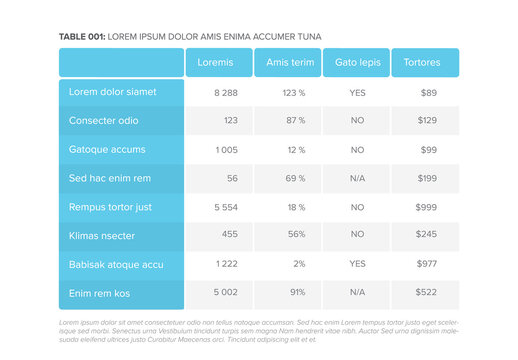

The image shows a table labeled "TABLE 001: LOREM IPSUM DOLOR AMIS ENIMA ACCUMER TUNA." It contains several columns and rows filled with placeholder text, commonly known as "Lorem Ipsum," which is used in design to fill space and demonstrate how text will appear in a layout.

### Table Structure:

#### Columns:
1. **Loremis**: Contains numerical values.
2. **Amis terim**: Contains percentages.
3. **Gato lepis**: Contains "YES," "NO," or "N/A."
4. **Tortores**: Contains currency values in dollars.

#### Rows:
- Each row represents a different category or item, labeled with placeholder text such as "Lorem dolor siamet," "Consecter odio," etc.
- The data in each row corresponds to the columns, providing a mix of numbers, percentages, binary options (YES/NO), and monetary values.

### Additional Details:
- The first column is highlighted in blue, possibly indicating a header or key category.
- The table is followed by a block of placeholder text, which is typically used to simulate a parag

In [12]:
IMAGE_URL = "https://t3.ftcdn.net/jpg/03/77/33/96/360_F_377339633_Rtv9I77sSmSNcev8bEcnVxTHrXB4nRJ5.jpg"
prompt = "이 이미지에 무엇이 보이는지 한국어로 상세히 설명해 주세요."

# prompt = 키워드 없이 두 번째 인자로 직접 전달
answer = multimodal_llm.stream(IMAGE_URL, prompt)
stream_response(answer)

In [1]:
#프롬프트 템플릿
from langchain_teddynote import logging
from dotenv import load_dotenv

#API KEY 정보 로드
load_dotenv()
logging.langsmith("CH01-Basic")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH01-Basic


In [3]:
#변수만 넣어서 작성가능 (문자열 전체 다 작성 필요 없음)

from langchain_teddynote.messages import stream_response  # 스트리밍 출력
from langchain_core.prompts import PromptTemplate

# template 정의
template = "{country}의 수도는 어디인가요?"

# from_template 메소드를 이용하여 PromptTemplate 객체 생성
prompt_template = PromptTemplate.from_template(template)
prompt_template

# prompt 생성
prompt = prompt_template.format(country="대한민국")
prompt

'대한민국의 수도는 어디인가요?'

In [ ]:
#LCEL Chain 생성
#질문(딕셔너리)이 들어오면 프롬프트 -> LLM -> 출력 파서로 연결된 체인 구성
#체인은 파이프 연산자 (|)를 입력하여 구분

from langchain_openai import ChatOpenAI

prompt = PromptTemplate.from_template('{topic}에 대해 쉽게 설명해주세요.')

model = ChatOpenAI(
    temperature = 0.1,
    model_name = "gpt-4o-mini"
)

chain = prompt | model

In [ ]:
#topic뿐만이 아닌 다른 곳에도 딕셔너리를 사용하여 여러 변수 사용 가능

input = {'topic' : '인공지능 모델의 학습 원리'}

chain.invoke(input)

AIMessage(content="인공지능 모델의 학습 원리는 크게 두 가지 단계로 나눌 수 있습니다: **훈련(Training)**과 **추론(Inference)**입니다.\n\n1. **훈련(Training)**:\n   - **데이터 수집**: 먼저, 모델이 학습할 데이터를 수집합니다. 이 데이터는 텍스트, 이미지, 소리 등 다양한 형태일 수 있습니다.\n   - **모델 구조 설정**: 인공지능 모델은 신경망(Neural Network)이라는 구조를 가지고 있습니다. 이 구조는 여러 층(Layer)으로 이루어져 있으며, 각 층은 노드(Node)로 구성되어 있습니다.\n   - **학습 과정**: 모델은 주어진 데이터를 통해 패턴을 학습합니다. 예를 들어, 고양이와 개의 이미지를 분류하는 모델이라면, 고양이와 개의 특징을 학습하게 됩니다. 이 과정에서 모델은 예측을 하고, 그 예측이 실제 정답과 얼마나 차이가 있는지를 계산합니다. 이 차이를 줄이기 위해 모델의 내부 파라미터(Weights)를 조정합니다. 이 과정을 여러 번 반복하면서 모델은 점점 더 정확한 예측을 하게 됩니다.\n\n2. **추론(Inference)**:\n   - 훈련이 완료된 모델은 새로운 데이터를 입력받아 예측을 합니다. 예를 들어, 새로운 이미지를 입력하면, 모델은 그 이미지가 고양이인지 개인지 판단합니다.\n   - 이 단계에서는 모델이 훈련 중에 학습한 패턴을 바탕으로 빠르게 결정을 내립니다.\n\n이러한 과정을 통해 인공지능 모델은 주어진 문제를 해결할 수 있는 능력을 갖추게 됩니다. 쉽게 말해, 많은 데이터를 통해 '배우고', 그 배운 내용을 바탕으로 새로운 상황에 '적용'하는 방식입니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 396, 'prompt_tokens': 21, 'total_tokens': 417, 'completion_tokens_

In [7]:
#출력 파서 체인 연결
#StrOutputParaser는 LLM이 생성한 출력 결과를 필요에 맞게 가공하고 구조화하는 단계
#파싱을 통해 핵심 내용을 추출하고 문자열로 변환. 
#답변을 이용해 특정 패턴 찾기 가능

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template('{topic}에 대해 쉽게 설명해주세요.')

model = ChatOpenAI(
    temperature = 0.1,
    model_name = "gpt-4o-mini"
)

output_parser = StrOutputParser()

#3단 체인 구성
chain = prompt | model | output_parser

input = {'topic' : '인공지능 모델의 학습 원리'}

chain.invoke(input)

"인공지능 모델의 학습 원리는 크게 두 가지 단계로 나눌 수 있습니다: **훈련(Training)**과 **테스트(Test)**입니다.\n\n1. **훈련(Training)**:\n   - **데이터 수집**: 먼저, 모델이 학습할 데이터를 수집합니다. 이 데이터는 이미지, 텍스트, 소리 등 다양한 형태일 수 있습니다.\n   - **모델 선택**: 학습할 인공지능 모델을 선택합니다. 예를 들어, 이미지 인식에는 CNN(합성곱 신경망)을, 자연어 처리에는 RNN(순환 신경망)이나 Transformer 모델을 사용할 수 있습니다.\n   - **학습 과정**: 모델은 주어진 데이터를 바탕으로 패턴을 학습합니다. 이 과정에서 모델은 입력 데이터와 정답(레이블)을 비교하여 오차를 계산합니다. 이 오차를 줄이기 위해 모델의 내부 파라미터(가중치)를 조정합니다. 이 과정을 여러 번 반복하면서 모델은 점점 더 정확하게 예측할 수 있게 됩니다.\n\n2. **테스트(Test)**:\n   - 훈련이 끝난 후, 모델의 성능을 평가하기 위해 새로운 데이터(테스트 데이터)를 사용합니다. 이 데이터는 모델이 훈련할 때 사용하지 않았던 데이터로, 모델이 실제로 얼마나 잘 작동하는지를 확인하는 데 사용됩니다.\n   - 테스트 결과를 바탕으로 모델의 성능을 분석하고, 필요하다면 모델을 개선하거나 다시 훈련할 수 있습니다.\n\n이러한 과정을 통해 인공지능 모델은 주어진 문제를 해결할 수 있는 능력을 갖추게 됩니다. 쉽게 말해, 인공지능 모델은 많은 데이터를 통해 '배우고', 그 배운 내용을 바탕으로 새로운 상황에서도 '예측'할 수 있는 능력을 가지게 되는 것입니다."

In [8]:
#프롬프트 템플릿 변경해서 적용
template = """
당신은 영어를 가르치는 10년차 영어 선생님입니다. 주어진 상황에 맞는 영어 회화를 작성해 주세요.
양식은 [FORMAT]을 참고하여 작성해 주세요.

#상황:
{question}

#FORMAT:
- 영어 회화:
- 한글 해석:
"""

# 프롬프트 템플릿을 이용하여 프롬프트를 생성합니다.
prompt = PromptTemplate.from_template(template)

# ChatOpenAI 챗모델을 초기화합니다.
model = ChatOpenAI(model_name="gpt-4-turbo")

# 문자열 출력 파서를 초기화합니다.
output_parser = StrOutputParser()

chain = prompt | model | output_parser  

print(chain.invoke({"question": "저는 식당에 가서 음식을 주문하고 싶어요"}))

- 영어 회화:
  Person: Hi, I’d like to have a table for one, please.
  Waiter: Of course, right this way. Here’s the menu. What would you like to order?
  Person: Could you recommend something?
  Waiter: Sure, our grilled salmon with lemon butter sauce is very popular. Would you like to try that?
  Person: That sounds great. I’ll have the grilled salmon, please.
  Waiter: Would you like anything to drink?
  Person: A glass of white wine, please.
  Waiter: Alright, your order will be ready soon. Enjoy your meal!

- 한글 해석:
  손님: 안녕하세요, 혼자 식사할 테이블을 부탁해요.
  웨이터: 물론입니다, 이쪽으로 오세요. 여기 메뉴입니다. 무엇을 주문하시겠어요?
  손님: 추천해주실 수 있나요?
  웨이터: 물론이죠, 저희 레몬 버터 소스가 곁들여진 그릴 연어가 매우 인기가 좋습니다. 드셔보시겠어요?
  손님: 좋아요. 그릴 연어 주세요.
  웨이터: 음료는 무엇으로 드릴까요?
  손님: 화이트 와인 한 잔 주세요.
  웨이터: 알겠습니다, 곧 준비될 거에요. 맛있게 드세요!


### Runnable 표준 인터페이스
- stream(): 응답의 청크를 스트리밍
- invoke(): 입력에 대해 체인 호출
- batch(): 여러 작업을 그룹으로 묶어서 일괄 처리. 여러 개의 딕셔너리로 이루어진 리스트로 인자로 받아 각 딕셔너리에서 특정 키 값으로 사용

In [ ]:
#batch() 함수로 일괄 처리

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = ChatOpenAI()
prompt = PromptTemplate.from_template("{topic} 에 대하여 3문장으로 설명해줘.")
chain = prompt | model | StrOutputParser()

#주어진 토픽 리스트를 batch 처리하는 함수 호출
chain.batch([{'topic': 'ChatGPT'}, {'topic': 'Instagram'}])

['ChatGPT는 OpenAI가 개발한 AI 대화 시스템으로, 사용자와 자연스럽게 대화를 나눌 수 있습니다. 주제에 따라 다양한 정보를 제공하고 질문에 답변할 뿐만 아니라, 창의적이고 흥미로운 대화도 가능합니다. ChatGPT는 다양한 분야에서 활용되며, 자연어 처리 기술의 발전을 보여줍니다.',
 'Instagram은 사진과 동영상을 공유하고 소셜 네트워크를 형성하는 앱이다. 사용자들은 팔로우, 좋아요, 댓글 등을 통해 다른 사람들과 소통하며 자신의 일상을 공유한다. 또한 인플루언서나 브랜드들이 광고를 올리거나 프로모션을 진행하는 플랫폼으로도 활용된다.']

In [10]:
#필요시 변수에 저장하고 따로 출력 가능
answer = chain.batch([{'topic' : 'ChatGPT'}, {'topic': 'Instagram'}])

answer[0]

'ChatGPT는 인공 지능 챗봇으로 자연어 처리 기술을 사용하여 대화를 함. 사용자의 질문이나 요청에 대답하거나 대화를 이어나갈 수 있으며, 다양한 분야에서 활용될 수 있음. ChatGPT는 언어 모델을 기반으로하여 계속적으로 학습하고 발전하여 더 자연스런 대화를 제공함.'

In [11]:
#max_concurrency로 동시 처리 가능한 최대 작업 수 지정 가능

chain.batch(
    [
        {"topic": "ChatGPT"},
        {"topic": "Instagram"},
        {"topic": "멀티모달"},
        {"topic": "프로그래밍"},
        {"topic": "머신러닝"},
    ],
    config={"max_concurrency": 3},
)

['ChatGPT는 인공지능 챗봇으로 사용자들과 대화를 나누는 데 사용됩니다. 이 기술은 자연어 처리 및 기계 학습 알고리즘을 기반으로하며 다양한 주제에 대해 대화할 수 있습니다. ChatGPT는 문제 해결, 정보 제공, 상담 등 다양한 목적으로 활용될 수 있습니다.',
 'Instagram은 소셜 미디어 플랫폼 중 하나로, 사용자들이 사진과 동영상을 공유하고 다른 사람들과 소통할 수 있는 서비스이다. 다양한 필터와 편집 기능을 제공하여 사용자가 자신의 콘텐츠를 더욱 멋지게 꾸밀 수 있다. 또한 해시태그를 활용하여 관심사나 주제에 맞는 콘텐츠를 쉽게 찾을 수 있다.',
 '멀티모달은 여러 다른 형태의 매체를 결합하여 정보를 전달하는 방식을 말합니다. 이는 텍스트, 이미지, 음성, 비디오 등 다양한 매체를 활용하여 사용자에게 다양한 경험을 제공합니다. 멀티모달을 활용하면 사용자들이 정보를 더 잘 이해하고 인지할 수 있으며 상호작용성이 높아집니다.',
 '프로그래밍은 컴퓨터에게 일련의 작업을 지시하는 과정이다. 코드를 작성하여 원하는 결과를 얻기 위해 알고리즘을 사용하고, 프로그래밍 언어를 통해 컴퓨터와 소통한다. 프로그래밍은 문제 해결능력을 기르고, 창의성을 끌어내며, 새로운 기술을 발전시키는 데 중요한 역할을 한다.',
 '머신러닝은 컴퓨터 시스템이 데이터를 분석하고 패턴을 학습하여 예측 또는 결정을 내리는 기술이다. 주어진 데이터를 기반으로 모델을 훈련시켜 새로운 데이터에 대한 예측을 수행한다. 머신러닝은 인공지능의 하위 분야로서 다양한 산업 분야에서 활용되고 있다.']

### 비동기 스트림
- 작업을 요청한 후 그 작업이 완료되기를 기다리면서 다른 작업 수행 가능
- astream() 함수 사용
- aincoke() 함수를 사용하여 비동기적 요청 사용 가능
- abatch() 함수로 여러 작업을 한꺼번에 비동기적 처리 가능

In [12]:
#비동기 스트림 사용
async for token in chain.astream({'topic' : 'Youtube'}):
    print(token, end = "", flush = True)

Youtube는 세계 최대의 온라인 동영상 플랫폼으로 사용자들이 다양한 콘텐츠를 시청하고 업로드할 수 있는 서비스이다. 누구나 무료로 이용할 수 있으며, 다양한 주제와 장르의 동영상을 즐길 수 있다. 또한 구독자 수, 조회 수 등의 지표를 통해 인기 있는 채널과 크리에이터를 찾을 수 있다.

In [13]:
my_precess = chain.ainvoke({'topic': 'NVDA'})

#비동기 작업 완료까지 프로그램이 진행되지 않도록 하기
await my_precess

'NVDA는 엔비디아 코퍼레이션의 주식 코드이며, 전 세계에서 인기 있는 그래픽 카드 및 시스템을 제조하는 회사입니다. 게임 산업 및 인공지능 분야에서 급속히 성장하고 있는 기업으로, 기술력과 혁신력으로 유명합니다. 주가는 주로 기술 혁신과 시장 동향에 따라 변동됩니다.'

In [14]:
my_abatch_process = chain.abatch(
    [{"topic": "YouTube"}, {"topic": "Instagram"}, {"topic": "Facebook"}]
)

await my_abatch_process

['YouTube는 전세계적으로 가장 인기있는 동영상 공유 플랫폼으로, 사용자들은 다양한 콘텐츠를 시청하고 업로드할 수 있습니다. 또한 광고 수익을 얻을 수 있는 유튜브 파트너 프로그램을 통해 크리에이터들이 수익을 창출할 수 있습니다. 더불어 라이브 스트리밍, 뮤직 비디오, 교육 자료 등 다양한 콘텐츠를 제공하며 일종의 온라인 커뮤니티 역할을 하고 있습니다.',
 'Instagram은 사진과 동영상을 공유하며 다른 사람들과 소통하는 소셜 미디어 플랫폼이다. 다양한 필터와 편집 기능을 제공하여 사용자들이 자신만의 콘텐츠를 만들 수 있다. 팔로워와 좋아요를 통해 사용자들간에 인기있는 콘텐츠를 공유하고 소셜 미디어 영향력을 확장할 수 있다.',
 '페이스북은 전 세계에서 가장 인기 있는 소셜 네트워크 플랫폼 중 하나이며, 사용자들이 친구들과 소통하고 콘텐츠를 공유할 수 있는 서비스를 제공합니다. 다양한 기능과 알고리즘을 통해 사용자들이 자신의 관심사에 맞는 콘텐츠를 손쉽게 찾을 수 있습니다. 또한 광고 플랫폼을 통해 기업들이 광고를 효과적으로 전달할 수 있는 플랫폼으로도 활용됩니다.']

In [15]:
#두 가지 작업을 동시에 처리 하느기 위한 모듈

from langchain_core.runnables import RunnableParallel

chain1 = (
    PromptTemplate.from_template("{country} 의 수도는 어디야?")
    | model
    | StrOutputParser()
)

# {country} 의 면적을 물어보는 체인을 생성합니다.
chain2 = (
    PromptTemplate.from_template("{country} 의 면적은 얼마야?")
    | model
    | StrOutputParser()
)

# 위의 2개 체인을 동시에 생성하는 병렬 실행 체인을 생성합니다.
combined = RunnableParallel(capital=chain1, area=chain2)

In [16]:
chain1.invoke({"country": "대한민국"})
chain2.invoke({"country": "미국"})
combined.invoke({"country": "대한민국"})

{'capital': '대한민국의 수도는 서울이다.', 'area': '대한민국의 총 면적은 약 100,363 제곱킬로미터 입니다.'}

In [17]:
combined.batch([{'country': '대한민국'}, {'country': '미국'}])

[{'capital': '대한민국의 수도는 서울이다.', 'area': '대한민국의 면적은 약 100,364km² 입니다.'},
 {'capital': '미국의 수도는 워싱턴 D.C.입니다.', 'area': '미국의 면적은 약 9.8백만 km² 입니다.'}]

In [20]:
#RunnablePassthrough => 딕셔너리 형식 대신 단순한 숫자 입력
#RunnablePassthrough.assign() => 기존 입력 딕셔너리 데이터 수정 or 확장

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

prompt = PromptTemplate.from_template("{num}의 10배는?")
llm = ChatOpenAI(temperature=0)

chain = prompt | llm

chain.invoke({"num": 5})

AIMessage(content='50', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 15, 'total_tokens': 16, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E6tWgf5cPt5Dfezu4S81tSEDHtRxh', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019face5-02b3-7662-9650-14961c572e76-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 1, 'total_tokens': 16, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [21]:
#RunnablPassthrough 사용

from langchain_core.runnables import RunnablePassthrough

RunnablePassthrough().invoke({"num": 10})

{'num': 10}

In [22]:
#입력된 데이터를 딕셔너리 형태로 자동 변환
runnable_chain = {"num": RunnablePassthrough()} | prompt | ChatOpenAI()

runnable_chain.invoke(10)

AIMessage(content='100.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 15, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E6tZ7cTWY97z4FDRMlcCDo9xcNThL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019face7-50c4-7b42-90fe-893fb00a34e7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 2, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [23]:
RunnablePassthrough().invoke({"num": 1})

{'num': 1}

In [ ]:
#새롭게 할당된 키-값 쌍을 결합
#assign 메소드를 쓰면 원래 있던 값이 삭제되는 것이 아닌 결합됨

(RunnablePassthrough.assign(new_num = lambda x: x["num"]*3)).invoke({"num": 1})

{'num': 1, 'new_num': 3}

In [25]:
from langchain_core.runnables import RunnableParallel

# RunnableParallel 인스턴스를 생성합니다. 이 인스턴스는 여러 Runnable 인스턴스를 병렬로 실행할 수 있습니다.
runnable = RunnableParallel(
    # RunnablePassthrough 인스턴스를 'passed' 키워드 인자로 전달합니다. 이는 입력된 데이터를 그대로 통과시키는 역할을 합니다.
    passed=RunnablePassthrough(),
    # 'extra' 키워드 인자로 RunnablePassthrough.assign을 사용하여, 'mult' 람다 함수를 할당합니다. 이 함수는 입력된 딕셔너리의 'num' 키에 해당하는 값을 3배로 증가시킵니다.
    extra=RunnablePassthrough.assign(mult=lambda x: x["num"] * 3),
    # 'modified' 키워드 인자로 람다 함수를 전달합니다. 이 함수는 입력된 딕셔너리의 'num' 키에 해당하는 값에 1을 더합니다.
    modified=lambda x: x["num"] + 1,
)

# runnable 인스턴스에 {'num': 1} 딕셔너리를 입력으로 전달하여 invoke 메소드를 호출합니다.
runnable.invoke({"num": 1})

{'passed': {'num': 1}, 'extra': {'num': 1, 'mult': 3}, 'modified': 2}

In [1]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from datetime import datetime


def get_today(a):
    # 오늘 날짜를 가져오기
    return datetime.today().strftime("%b-%d")


# 오늘 날짜를 출력
get_today(None)

'Jul-29'

In [3]:
#RuannableLambda, RunnablePassthrough 사용 체인 구성

from langchain_core.runnables import RunnablePassthrough, RunnableLambda

prompt = PromptTemplate.from_template(
    "{today}가 생일인 유명인 {n}명을 나열하세요. 생년월일을 표기해 주세요."
)

llm = ChatOpenAI(
    temperature= 0,
    model_name = "gpt-4o-mini",
    request_timeout=10, # 10초 이상 응답 없으면 바로 에러를 띄움
    max_retries=1 # 재시도 횟수 제한
)

chain = (
    {"today": RunnableLambda(get_today), "n": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print(chain.invoke(3))

다음은 7월 29일에 태어난 유명인 3명입니다:

1. **버지니아 울프 (Virginia Woolf)** - 1882년 1월 25일
2. **미카엘 잔 (Mikael Jansson)** - 1964년 7월 29일
3. **올리비아 뉴턴-존 (Olivia Newton-John)** - 1948년 9월 26일

(참고: 올리비아 뉴턴-존은 7월 29일이 아닌 9월 26일에 태어났습니다. 다른 유명인을 추가로 원하시면 말씀해 주세요.)


In [7]:
#itemgetter 사용
from operator import itemgetter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_openai import ChatOpenAI

#문장의 길이 반환 함수
def length_function(text):
    return len(text)

#두 문장의 길이를 곱한 값을 반환하는 함수
def _multiple_length_function(text1, text2):
    return len(text1) * len(text2)

#딕셔너리에 두 값을 반환
def multiple_length_function(_dict):
    return _multiple_length_function(_dict["text1"], _dict["text2"])


prompt = ChatPromptTemplate.from_template("{a} + {b}는 무엇인가요?")
model = ChatOpenAI(
    temperature=0,
    model_name = 'gpt-4o-mini'
)

chain1 = prompt | model

chain = (
    {
        "a" : itemgetter("word1") | RunnableLambda(length_function),
        "b" : {"text1": itemgetter("word1"), "text2": itemgetter("word2")}
        | RunnableLambda(multiple_length_function)
    }
    | prompt
    | model
)

chain.invoke({"word1": "hello", "word2": "world"})

AIMessage(content='5 + 25는 30입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 16, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b1446f74b5', 'id': 'chatcmpl-E6u738Ck5lmsXqcENT5ayGq59fvOu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fad07-6d3d-7793-9e23-9cd39ffa50c2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 9, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})